# PageIndex vs Vector RAG — Full Demo & Evaluation

This notebook runs **two RAG approaches** on the same PDF and compares them using **GEval** (5 metrics).

| | Approach | Retrieval | Chunking |
|---|---|---|---|
| 🗂 | **PageIndex RAG** | LLM navigates a hierarchical structure tree | Semantic sections via LLM |
| 🔍 | **Vector RAG** | FAISS cosine search over sentence embeddings | Section-based (PageIndex boundaries) |

Text extraction for both approaches uses **Docling** (markdown tables, structured text).

## 0. Setup

In [1]:
import sys, subprocess
from pathlib import Path

SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', '-r', '../requirements.txt'],
    capture_output=True, text=True
)
print('Dependencies OK' if r.returncode == 0 else r.stderr[-300:])

Dependencies OK


In [2]:
import json, warnings
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import Markdown, display, JSON
warnings.filterwarnings('ignore')

from index_pdf  import find_pdf, run_indexing, DATA_DIR, RESULTS_DIR, print_structure_tree
from qa_system  import load_structure, find_structure_json, answer_question, flatten_nodes, DEFAULT_QUESTION as QUESTION
from vector_rag import vector_rag_answer
from evaluation import compare_answers

print(f'Question:\n{QUESTION}')

Question:
How did the company's total revenue and operating margin change in Q1 FY25 compared to the previous year, and which business segments contributed most to this change?


---
## Part 1 — PageIndex: Hierarchical Structure

In [3]:
pdf_path  = find_pdf(DATA_DIR)
structure = run_indexing(pdf_path, RESULTS_DIR)
json_path = find_structure_json(RESULTS_DIR)

display(Markdown(f"""
**Document:** {structure.get('doc_name', '')}

**Description:** {structure.get('doc_description', '')}
"""))

[index_pdf] Cached result found: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Page_Index/results/q1-fy25-earnings_structure.json



**Document:** q1-fy25-earnings.pdf

**Description:** A comprehensive financial and operational report detailing The Walt Disney Company's first-quarter fiscal 2025 performance, including revenue growth, segment-specific results, guidance for the fiscal year, and key metrics for streaming, parks, and sports, along with non-GAAP financial measures and forward-looking statements.


In [4]:
print('=== PageIndex Structure Tree ===')
print_structure_tree(structure.get('structure', []))

=== PageIndex Structure Tree ===
0000  THE WALT DISNEY COMPANY REPORTS FIRST QUARTER EARNINGS FOR FISCAL 2025  [p1–1]
  └─ 0001  Financial Results for the Quarter  [p1–1]
    └─ 0002  Key Points  [p1–1]
0003  Guidance and Outlook  [p2–2]
  └─ 0004  Star India deconsolidated in Q1  [p2–2]
  └─ 0005  Q2 Fiscal 2025  [p2–2]
  └─ 0006  Fiscal Year 2025  [p2–2]
  └─ 0007  Message From Our CEO  [p2–2]
0008  SUMMARIZED FINANCIAL RESULTS  [p3–3]
  └─ 0009  SUMMARIZED SEGMENT FINANCIAL RESULTS  [p3–3]
0010  DISCUSSION OF FIRST QUARTER SEGMENT RESULTS  [p4–4]
  └─ 0011  Star India  [p4–4]
  └─ 0012  Entertainment  [p4–4]
    └─ 0013  Linear Networks  [p5–5]
    └─ 0014  Direct-to-Consumer  [p5–7]
    └─ 0015  Content Sales/Licensing and Other  [p7–7]
  └─ 0016  Sports  [p7–7]
    └─ 0017  Domestic ESPN  [p8–8]
    └─ 0018  International ESPN  [p8–8]
    └─ 0019  Star India  [p8–8]
  └─ 0020  Experiences  [p9–9]
    └─ 0021  Domestic Parks and Experiences  [p9–9]
    └─ 0022  International Parks 

In [5]:
flat_nodes = flatten_nodes(structure.get('structure', []))
df_nodes = pd.DataFrame([
    {
        'node_id': n['node_id'],
        'depth'  : n['depth'],
        'title'  : '  ' * n['depth'] + n['title'],
        'pages'  : f"{n['start_index']}\u2013{n['end_index']}",
        'summary': (n['summary'] or '')[:110] + '\u2026',
    }
    for n in flat_nodes if n['node_id']
])
pd.set_option('display.max_colwidth', 120)
df_nodes.style.hide(axis='index')

node_id,depth,title,pages,summary
0000,0,THE WALT DISNEY COMPANY REPORTS FIRST QUARTER EARNINGS FOR FISCAL 2025,1–1,The partial document provides a summary of The Walt Disney Company's financial performance for the first fisca…
0001,1,Financial Results for the Quarter,1–1,The partial document provides a summary of The Walt Disney Company's financial performance for the first fisca…
0002,2,Key Points,1–1,The partial document provides a summary of The Walt Disney Company's financial performance for the first quart…
0003,0,Guidance and Outlook,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0004,1,Star India deconsolidated in Q1,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0005,1,Q2 Fiscal 2025,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0006,1,Fiscal Year 2025,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0007,1,Message From Our CEO,2–2,"The partial document outlines Disney's financial guidance and outlook for fiscal 2025, highlighting key perfor…"
0008,0,SUMMARIZED FINANCIAL RESULTS,3–3,The partial document provides a summarized overview of financial results for the first quarter of fiscal years…
0009,1,SUMMARIZED SEGMENT FINANCIAL RESULTS,3–3,The partial document provides a summarized overview of financial results for the first quarter of fiscal years…


---
## Part 2 — Answer Generation

Both RAG approaches answer the **same question** from the same PDF.

In [6]:
display(Markdown(f'> **Question:** *{QUESTION}*'))

> **Question:** *How did the company's total revenue and operating margin change in Q1 FY25 compared to the previous year, and which business segments contributed most to this change?*

### 2a. PageIndex RAG
LLM reads the structure tree → selects relevant nodes → Docling extracts those pages → Azure OpenAI answers.

In [7]:
pi_result = answer_question(QUESTION, pdf_path, json_path)

nodes_md = '\n'.join(
    f"- `[{n['node_id']}]` **{n['title']}** \u2014 pages {n['pages']}"
    for n in pi_result['relevant_nodes']
)
pages_md = ', '.join(f"{s}\u2013{e}" for s, e in pi_result['pages_retrieved'])
display(Markdown(f"""
**Sections selected by LLM navigation:**
{nodes_md}

**Pages retrieved (Docling):** {pages_md}
"""))

[qa_system] Loaded 43 nodes from index.
[qa_system] Relevant nodes selected: ['0008', '0009', '0010', '0013', '0014', '0020']
[qa_system] Fetching pages: [(3, 3), (4, 4), (5, 5), (5, 7), (9, 9)]
[qa_system] Parsing PDF with Docling: q1-fy25-earnings.pdf (one-time, cached)…
[qa_system] Docling parsing complete.
[qa_system] Generating answer...



**Sections selected by LLM navigation:**
- `[0008]` **SUMMARIZED FINANCIAL RESULTS** — pages 3–3
- `[0009]` **SUMMARIZED SEGMENT FINANCIAL RESULTS** — pages 3–3
- `[0010]` **DISCUSSION OF FIRST QUARTER SEGMENT RESULTS** — pages 4–4
- `[0013]` **Linear Networks** — pages 5–5
- `[0014]` **Direct-to-Consumer** — pages 5–7
- `[0020]` **Experiences** — pages 9–9

**Pages retrieved (Docling):** 3–3, 4–4, 5–5, 5–7, 9–9


In [8]:
display(Markdown(f"""
---
### \U0001f5c2 PageIndex RAG \u2014 Answer

{pi_result['answer']}
"""))


---
### 🗂 PageIndex RAG — Answer

### Revenue and Operating Margin Changes in Q1 FY25

• **Total Revenue**: Increased by 5%, from $23,549 million in Q1 FY24 to $24,690 million in Q1 FY25.  
• **Operating Margin (Total Segment Operating Income)**: Increased by 31%, from $3,876 million in Q1 FY24 to $5,060 million in Q1 FY25.

#### Business Segment Contributions to Revenue and Operating Margin Changes:
• **Entertainment**:  
  ◦ Revenue increased by 9%, from $9,981 million to $10,872 million.  
  ◦ Operating income surged by 95%, from $874 million to $1,703 million.  
  ◦ Key drivers:  
    - Content Sales/Licensing and Other revenue grew by 34%, with operating income improving from a loss of $224 million to $312 million, driven by strong theatrical releases like *Moana 2*.  
    - Direct-to-Consumer revenue increased by 9%, with operating income improving from a loss of $138 million to $293 million, due to higher subscription rates and more subscribers.  
    - Linear Networks revenue declined by 7%, and operating income decreased by 11%, primarily due to lower international performance and the impact of the Star India transaction.  

• **Sports**:  
  ◦ Revenue remained flat at $4,850 million.  
  ◦ Operating income improved significantly from a loss of $103 million to $247 million.  
  ◦ Key drivers:  
    - Domestic ESPN revenue grew by 9%, while international ESPN revenue increased by 7%.  
    - Star India revenue dropped by 90%, but its operating income improved from a loss of $315 million to a gain of $9 million.  

• **Experiences**:  
  ◦ Revenue increased by 3%, from $9,132 million to $9,415 million.  
  ◦ Operating income remained flat at $3,110 million.  
  ◦ Key drivers:  
    - International Parks & Experiences operating income rose by 28%, driven by higher guest spending and attendance.  
    - Domestic Parks & Experiences operating income declined by 5%, impacted by hurricanes and higher costs.  

📌 **Key Takeaway**: The Entertainment segment was the largest contributor to the company's revenue and operating margin growth in Q1 FY25, driven by strong performance in Content Sales/Licensing and Direct-to-Consumer operations.


### 2b. Section-Based Vector RAG
Section chunks (from PageIndex boundaries) → sentence-transformers embeddings → FAISS top-5 → Azure OpenAI answers.

In [9]:
vr_result = vector_rag_answer(QUESTION, pdf_path, structure, top_k=5)

chunks_md = '\n'.join(
    f"- `[{c['node_id']}]` **{c['title']}** \u2014 pages {c['pages']}"
    for c in vr_result['retrieved_chunks']
)
display(Markdown(f"""
**Top-5 chunks retrieved by FAISS (sentence-transformers):**
{chunks_md}
"""))

[vector_rag] Created 22 section chunks from 22 unique page ranges.
[vector_rag] Loading embedding model: all-MiniLM-L6-v2…
[vector_rag] Embedding model loaded.
[vector_rag] Embedding 22 chunks…
[vector_rag] FAISS index built — 22 vectors, dim=384.
[vector_rag] Retrieved 5 chunks for the query.
[vector_rag] Generating answer…



**Top-5 chunks retrieved by FAISS (sentence-transformers):**
- `[0039]` **Total segment operating income** — pages 19–20
- `[0000]` **THE WALT DISNEY COMPANY REPORTS FIRST QUARTER EARNINGS FOR FISCAL 2025** — pages 1–1
- `[0008]` **SUMMARIZED FINANCIAL RESULTS** — pages 3–3
- `[0003]` **Guidance and Outlook** — pages 2–2
- `[0020]` **Experiences** — pages 9–9


In [10]:
display(Markdown(f"""
---
### \U0001f50d Vector RAG \u2014 Answer

{vr_result['answer']}
"""))


---
### 🔍 Vector RAG — Answer

### Q1 FY25 Revenue and Operating Margin Changes with Key Segment Contributions

• **Total Revenue**: Increased by 5% to $24.7 billion in Q1 FY25, up from $23.5 billion in Q1 FY24.  
• **Total Segment Operating Income**: Increased by 31% to $5.1 billion in Q1 FY25, up from $3.9 billion in Q1 FY24.  

• **Key Segment Contributions**:
  ◦ **Entertainment**: Operating income rose by 95% to $1.7 billion, driven by strong box office performance and improved profitability in Direct-to-Consumer streaming.  
  ◦ **Sports**: Operating income improved significantly from a $103 million loss in Q1 FY24 to $247 million in Q1 FY25, supported by higher domestic ESPN advertising revenue (+15%).  
  ◦ **Experiences**: Operating income remained flat at $3.1 billion, with international parks showing a 28% increase in operating income, offsetting a 5% decline in domestic parks due to hurricane impacts and pre-opening expenses.  

📌 **Key Takeaway**: The 31% growth in total segment operating income was primarily driven by the Entertainment and Sports segments, with Entertainment seeing a 95% surge in operating income and Sports recovering from a prior-year loss.


---
## Part 3 — GEval Comparison (5 Metrics)

**Evaluation framework:** DeepEval GEval  
**Judge LLM:** Azure OpenAI gpt-4o  
**Reference:** Full PDF extracted via Docling (up to 40 000 chars) — no gold-standard answer needed

| Metric | What it measures |
|---|---|
| Answer Relevancy | Does the answer address the question? |
| Faithfulness | Every claim grounded in retrieved content? |
| Completeness | Key PDF facts covered? |
| Conciseness | Appropriately detailed, not verbose or sparse? |
| Coherence | Logically structured and easy to follow? |

In [11]:
comparison = compare_answers(QUESTION, pi_result, vr_result, pdf_path)

[evaluation] Extracting full PDF context for Completeness metric…
[evaluation] Full PDF context: 40,017 chars.

[evaluation] Evaluating 'PageIndex RAG' across 5 metrics…
  • Answer Relevancy… 

Output()

score=1.0
  • Faithfulness… 

Output()

score=0.3
  • Completeness… 

...

score=0.9
  • Conciseness… 

Output()

score=1.0
  • Coherence… 

Output()

score=0.9


### 3a. Score Summary

In [12]:
df_summary = pd.DataFrame(comparison['summary'])
df_summary.columns = ['Metric', 'PageIndex RAG', 'Vector RAG', 'Winner']

def color_winner(row):
    styles = [''] * len(row)
    if row['Winner'] == 'PageIndex RAG':
        styles[1] = 'background-color:#d4edda;font-weight:bold'
    elif row['Winner'] == 'Vector RAG':
        styles[2] = 'background-color:#d4edda;font-weight:bold'
    else:
        styles[1] = styles[2] = 'background-color:#fff3cd'
    return styles

display(df_summary.style
    .apply(color_winner, axis=1)
    .hide(axis='index')
    .format({'PageIndex RAG': '{:.3f}', 'Vector RAG': '{:.3f}'}))

Metric,PageIndex RAG,Vector RAG,Winner
Answer Relevancy,1.000,1.000,Tie
Faithfulness,0.300,1.000,Vector RAG
Completeness,0.900,0.900,Tie
Conciseness,0.900,1.000,Vector RAG
Coherence,0.900,0.900,Tie


### 3b. Score Chart

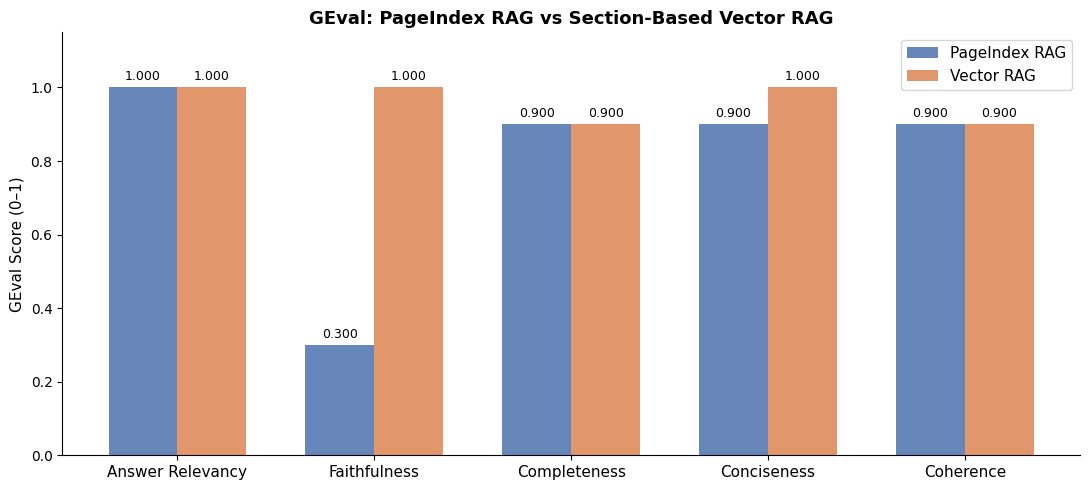

Chart saved → results/geval_comparison.png


In [13]:
metrics   = [r['metric']          for r in comparison['summary']]
pi_scores = [r['pageindex_score'] for r in comparison['summary']]
vr_scores = [r['vector_score']    for r in comparison['summary']]

x = range(len(metrics))
w = 0.35
fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar([i - w/2 for i in x], pi_scores, w, label='PageIndex RAG', color='#4C72B0', alpha=0.85)
b2 = ax.bar([i + w/2 for i in x], vr_scores,  w, label='Vector RAG',    color='#DD8452', alpha=0.85)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=9)
ax.set_xticks(list(x))
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel('GEval Score (0\u20131)', fontsize=11)
ax.set_title('GEval: PageIndex RAG vs Section-Based Vector RAG', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/geval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved \u2192 results/geval_comparison.png')

### 3c. Detailed Reasoning — PageIndex RAG

In [14]:
for r in comparison['pageindex']['scores']:
    display(Markdown(f"""
**{r['metric']}** \u2014 score: `{r['score']}`

> {r['reason']}

---"""))


**Answer Relevancy** — score: `1.0`

> The response directly addresses the question by providing detailed changes in total revenue and operating margin for Q1 FY25 compared to the previous year. It also thoroughly explains the contributions of each business segment, including specific revenue and operating income changes, as well as key drivers for these changes. The response is comprehensive, focused, and does not introduce unrelated information, fully aligning with the evaluation steps.

---


**Faithfulness** — score: `0.3`

> The response includes some accurate data points, such as the overall revenue and operating margin changes, and segment-level revenue and operating income changes for Entertainment, Sports, and Experiences. However, it contains unverifiable claims, such as the mention of 'Moana 2' as a driver for Content Sales/Licensing revenue growth, which is not supported by the Retrieval Context. Additionally, the claim about higher subscription rates and more subscribers driving Direct-to-Consumer revenue growth is not explicitly traceable. These shortcomings reduce the alignment with the evaluation criteria.

---


**Completeness** — score: `0.9`

> The response aligns well with the evaluation steps by clearly addressing the Input question. It accurately reports the total revenue increase of 5% and operating margin growth of 31%, matching the Context. It also provides detailed segment contributions, highlighting Entertainment as the largest contributor, supported by specific metrics like the 95% increase in operating income and key drivers such as theatrical releases and subscription growth. Minor omissions include the lack of explicit mention of the 27% increase in income before taxes, which could provide additional context for overall financial performance.

---


**Conciseness** — score: `0.9`

> The Actual Output comprehensively addresses the Input by detailing changes in total revenue and operating margin, as well as identifying the contributions of specific business segments. It avoids excessive repetition and provides clear, detailed breakdowns for each segment, including key drivers. However, minor verbosity in segment details slightly impacts conciseness.

---


**Coherence** — score: `0.9`

> The response is logically structured, with a clear progression of ideas from overall revenue and operating margin changes to detailed segment contributions. Information flows naturally and is easy to understand, with specific metrics and drivers provided for each segment. The reasoning is consistent throughout, with no contradictions or gaps in logic. However, minor improvements could be made in summarizing the flat performance of the Sports and Experiences segments to enhance clarity.

---

### 3d. Detailed Reasoning — Vector RAG

In [15]:
for r in comparison['vector_rag']['scores']:
    display(Markdown(f"""
**{r['metric']}** \u2014 score: `{r['score']}`

> {r['reason']}

---"""))


**Answer Relevancy** — score: `1.0`

> The response directly addresses the question by providing detailed changes in total revenue and operating margin for Q1 FY25 compared to the previous year. It also identifies the specific business segments contributing to these changes, with clear data and explanations for each segment. The output is complete, focused, and does not introduce unrelated information.

---


**Faithfulness** — score: `1.0`

> The response aligns strongly with the evaluation steps. The Input question is clear and directly addressed, with all factual claims in the Actual Output traceable to the Retrieval Context. The revenue increase of 5% to $24.7 billion and the 31% rise in total segment operating income to $5.1 billion are explicitly supported by the context. Key segment contributions, such as the 95% increase in Entertainment operating income, the Sports segment's recovery to $247 million, and the flat performance of Experiences with detailed breakdowns, are all accurately reflected. No hallucinations or unverifiable statements are present.

---


**Completeness** — score: `0.9`

> The response aligns well with the evaluation steps by clearly addressing the Input question. It accurately identifies the changes in total revenue (+5%) and operating margin (+31%) for Q1 FY25 compared to Q1 FY24, as stated in the Context. Additionally, it highlights the key business segments contributing to these changes, including Entertainment (+95% operating income), Sports (recovery from a loss to $247 million), and Experiences (flat operating income with international parks offsetting domestic declines). However, the Actual Output could have included more granular details, such as specific revenue figures for each segment, to further enhance comprehensiveness.

---


**Conciseness** — score: `1.0`

> The response fully aligns with the evaluation steps. It addresses all aspects of the Input by providing detailed changes in total revenue and operating margin, as well as identifying the key business segments contributing to these changes. The information is specific, with precise figures and percentages for revenue, operating income, and segment performance. The response avoids unnecessary repetition or padding, and the level of detail is appropriate without being overly verbose. The summary at the end reinforces the key insights effectively, ensuring clarity and conciseness.

---


**Coherence** — score: `0.9`

> The response is logically structured, presenting revenue and operating margin changes followed by detailed contributions from key segments in a clear sequence. The flow is natural and easy to follow, with no contradictions in the reasoning. The explanation highlights specific drivers for each segment's performance, such as box office success for Entertainment and ESPN advertising for Sports. However, the flat performance of Experiences could have been elaborated further to provide a more balanced analysis.

---

---
## Part 4 — Save All Results

In [16]:
out = {
    'question'    : QUESTION,
    'pageindex'   : {'answer': pi_result['answer'], 'nodes': pi_result['relevant_nodes']},
    'vector_rag'  : {'answer': vr_result['answer'], 'chunks': vr_result['retrieved_chunks']},
    'geval'       : comparison['summary'],
    'geval_detail': {
        'pageindex' : comparison['pageindex']['scores'],
        'vector_rag': comparison['vector_rag']['scores'],
    },
}
out_path = Path('../results/full_comparison.json')
out_path.write_text(json.dumps(out, indent=2, ensure_ascii=False))
print(f'\u2713 Full results saved \u2192 {out_path}')

tally = Counter(r['winner'] for r in comparison['summary'])
display(Markdown(f"""
### Final Tally
| Approach | Metrics Won |
|---|---|
| PageIndex RAG | {tally.get('PageIndex RAG', 0)} |
| Vector RAG    | {tally.get('Vector RAG', 0)} |
| Tie           | {tally.get('Tie', 0)} |
"""))

✓ Full results saved → ../results/full_comparison.json



### Final Tally
| Approach | Metrics Won |
|---|---|
| PageIndex RAG | 0 |
| Vector RAG    | 2 |
| Tie           | 3 |
